In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import time, os, sys
from tqdm import tqdm
from glob import glob
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from photutils.aperture import RectangularAperture

sys.path.append('/Users/isabelkain/Desktop/SCALES/scales-data-analysis/psf-fitting-tool')
sys.path.append('/Users/isabelkain/Desktop/SCALES/scales-data-analysis')

from utils import *
from enslitted_energy_utils import *

%load_ext autoreload
%autoreload 2

plotpath = '/Users/isabelkain/Desktop/SCALES/scales-data-analysis/temp-enslitted-energy-Lband'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# Read in datacube, wavelengths, rough lenslet positions, best-fit lenslet positions

fc = '/Users/isabelkain/Desktop/SCALES/CD3/IFS_monochrometer_scans/L-prism/data/20251027_mono_cube_L_new.fits'
fl = '/Users/isabelkain/Desktop/SCALES/CD3/IFS_monochrometer_scans/L-prism/Lnew_lams.fits'
fp = '/Users/isabelkain/Desktop/SCALES/CD3/IFS_monochrometer_scans/L-prism/L_positions_new.fits'
fr = '/Users/isabelkain/Desktop/SCALES/CD3/IFS_monochrometer_scans/L-prism/L_psf_fitting_results.fits'

cube = fits.getdata(fc) # (nlams, nx, ny)
lams = fits.getdata(fl) # (nlams)
pos = fits.getdata(fp) # (nlams, nx, ny, 6)  > [x_center, x_start, x_end, y_center, y_start, y_end]
res = fits.getdata(fr) # (8, nx, ny) > [x_cen, y_cen, x_fwhm, y_fwhm, theta, fwhm||, fwhm|_, quality_flags]


# If rotation angle is fitted, read it in; otherwise, hardcoded value from CD3 LowRes-L measurement
rot_angle = 71.58


# Renormalize each slice of cube such that median=0
for i in range(np.shape(cube)[0]):
    medbg = np.nanmedian(cube[i])
    cube[i] -= medbg
    
# Set all pixels <0 to 0 FIXME this makes my problems go away but is probably a bad analysis choice
cube[cube < 0.] = 0.

# Calculate "squished" cube (sum along wavelength axis)
squish = np.sum(cube, axis=0)


NUM SAMPLES: 21 MAXWIDTH: 10.0


/Users/isabelkain/Desktop/SCALES/scales-data-analysis/enslitted_energy_utils.py:268: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  
/Users/isabelkain/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


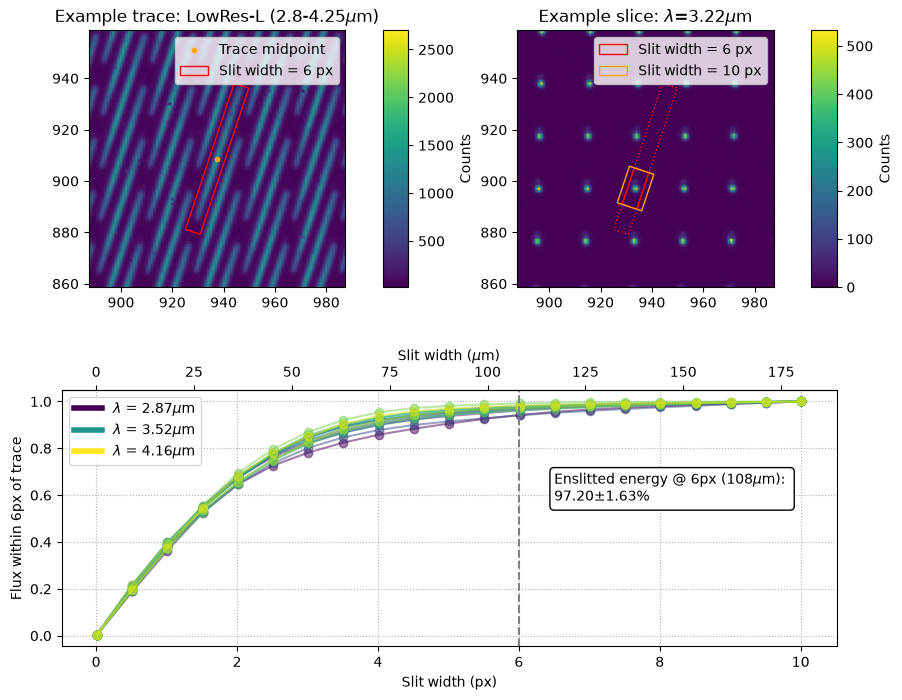

In [13]:
# Manually select single trace to fit across all wavelength slices
trace_index = (45, 50)

# Set path to save plots
plotpath = '/Users/isabelkain/Desktop/SCALES/scales-data-analysis/temp-enslitted-energy-Lband'

# Measure EE of trace
slit_widths, fluxes, apertures = measure_EE_bywav(cube, lams, res, trace_index, rot_angle=rot_angle, plotpath=plotpath)


[]

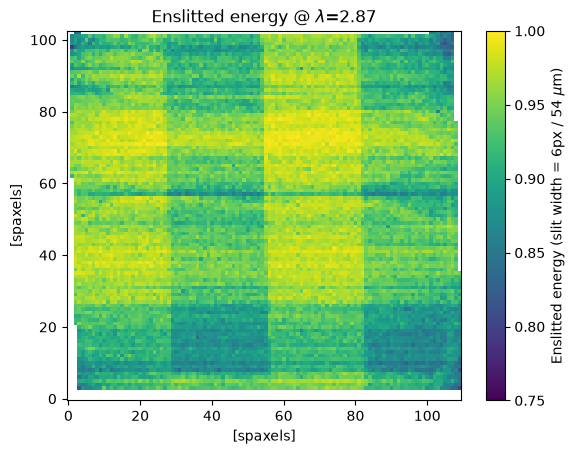

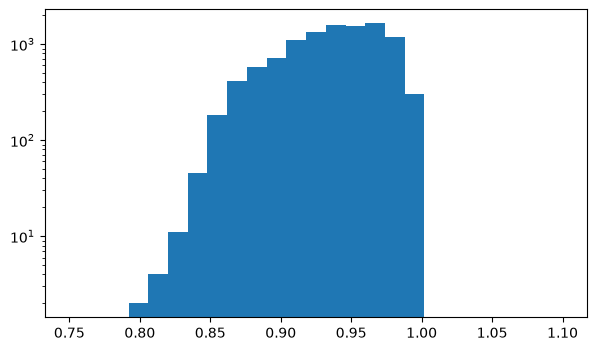

In [21]:
# Isolate single wavelength to work with
wav_index = 0

# # Measure EE for every trace in single wavelength slice
# slit_widths, fluxes, apertures = measure_EE_byslice(cube[wav_index], res, wav_index=wav_index, rot_angle=rot_angle)

# Identify indices in fluxes array where width=6px, width=10px
loc6 = np.argmin(np.abs(slit_widths-6.))
loc10 = np.argmin(np.abs(slit_widths-10.))

# Construct EE map  across selected wavelength slice
EE_map = fluxes[:,:,loc6] / fluxes[:,:,loc10]

# Plot 2D EE map
plt.imshow( EE_map, origin='lower', vmin=0.75, vmax=1.0 )
plt.colorbar(label=r'Enslitted energy (slit width = 6px / 54 $\mu$m)')
plt.xlabel('[spaxels]')
plt.ylabel('[spaxels]')
plt.title(f'Enslitted energy @ $\lambda$={lams[wav_index]:0.2f}')

# Plot histogram of measured enslitted energies
plt.figure(figsize=(7,4))
plt.hist( np.ravel(EE_map), bins=25, range=(0.75, 1.1) )
plt.semilogy()

[]

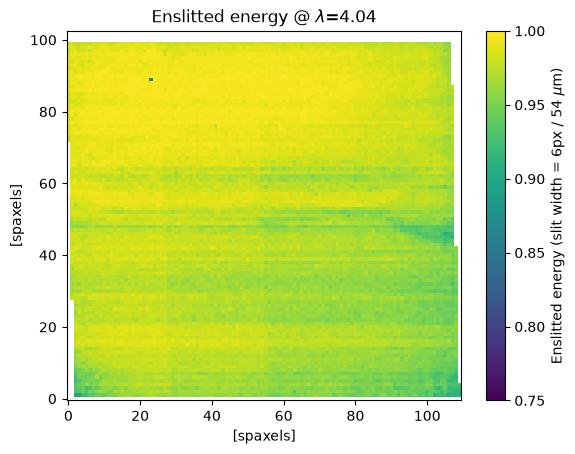

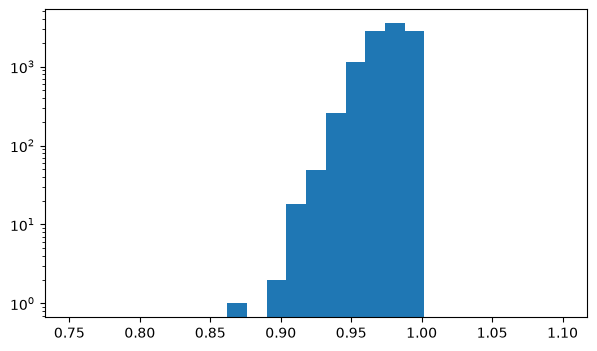

In [22]:
# Isolate single wavelength to work with
wav_index = 50

# Measure EE for every trace in single wavelength slice
slit_widths, fluxes, apertures = measure_EE_byslice(cube[wav_index], res, wav_index=wav_index, rot_angle=rot_angle)

# Identify indices in fluxes array where width=6px, width=10px
loc6 = np.argmin(np.abs(slit_widths-6.))
loc10 = np.argmin(np.abs(slit_widths-10.))

# Construct EE map  across selected wavelength slice
EE_map = fluxes[:,:,loc6] / fluxes[:,:,loc10]

# Plot 2D EE map
plt.imshow( EE_map, origin='lower', vmin=0.75, vmax=1.0 )
plt.colorbar(label=r'Enslitted energy (slit width = 6px / 54 $\mu$m)')
plt.xlabel('[spaxels]')
plt.ylabel('[spaxels]')
plt.title(f'Enslitted energy @ $\lambda$={lams[wav_index]:0.2f}')

# Plot histogram of measured enslitted energies
plt.figure(figsize=(7,4))
plt.hist( np.ravel(EE_map), bins=25, range=(0.75, 1.1) )
plt.semilogy()